In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. 시드 고정 및 데이터 개수 설정
np.random.seed(42)# 누가 실행해도 똑같은 랜덤 값이 나오도록 고정

n = 10000# 생성할 가상 반도체 칩 설계 데이터의 개수 (1만 개)

In [3]:
# ============================
# INPUT FEATURES (입력 변수 = 설계 조건)
# ============================

# Structural features- 회로의 물리적인 형태와 관련된 변수들
gate_count = np.random.randint(1000, 50000, n)         # gates# 게이트 수 (1,000 ~ 50,000개)
wire_length = np.random.uniform(100, 10000, n)         #  um# 선 길이 (단위: um)
fanout = np.random.randint(1, 20, n)   # 하나의 게이트가 구동하는 다음 게이트의 수
logic_depth = np.random.randint(5, 80, n)    # 입력부터 출력까지 거치는 게이트의 최대 깊이

# Electrical features - 동작 환경과 관련된 변수들
frequency = np.random.uniform(100e6, 2e9, n)           # Hz # 동작 주파수 (100MHz ~ 2GHz)
vdd = np.random.uniform(0.7, 1.2, n)                   # V # 공급 전압 (0.7V ~ 1.2V)
toggle_rate = np.random.uniform(0.01, 0.5, n) # 신호가 0에서 1로 변하는 전환 확률

# Environmental feature - 외부 환경 요인
temperature = np.random.uniform(250, 400, n)           # Kelvin # 절대 온도 (단위: Kelvin)

In [4]:
# ============================ 라이브러리 준비 및 물리 공식 기반 가상 데이터 생성
# INTERNAL PHYSICAL PARAMETERS (내부 물리 파라미터 계산)
# ============================
#전력과 지연 시간을 계산하기 위한 중간 과정 (정전 용량 및 열 전압)
capacitance = ( # 전체 정전 용량 계산
    gate_count * 1e-15 +
    fanout * 5e-15 +
    wire_length * 1e-18
)

k = 1.38e-23
q = 1.602e-19

thermal_voltage = (k * temperature) / q

In [5]:
# ============================
# OUTPUT TARGETS 출력 목표값 = 우리가 예측할 PPA 정답지
# ============================

# Dynamic Power (mW) - 스위칭할 때 소모되는 전력
dynamic_power = (
    toggle_rate *
    capacitance *
    (vdd ** 2) *
    frequency
) * 1e3


# Leakage Power (mW) - 가만히 있어도 새어나가는 전력 (온도에 민감)
leakage_power = (
    gate_count *
    vdd *
    np.exp((temperature - 300)/80)
    * 5e-8
) * 1e3


# Total Power (mW) 동적 전력 + 누설 전력 + 약간의 노이즈(현실성 부여)
power = dynamic_power + leakage_power + np.random.normal(
    0, 0.02 * dynamic_power.std(), n #noise줄임
)


# Delay (ns) - 회로 동작 속도
delay = (
    (capacitance * vdd / 1e-3) * 1e9
    + logic_depth * 0.05
    + (temperature - 300) * 0.08
    + np.random.normal(0, 0.2, n)
)


# Area (um²) - 칩이 차지하는 물리적 크기
area = (
    gate_count * 0.8
    + wire_length * 0.12
    + fanout * 15
    + np.random.normal(0, 400, n)
)
# 노이즈 때문에 물리적으로 불가능한 음수(-) 값이 나오는 것을 방지 (최소값을 0.001로 고정)
power = np.clip(power, 0.001, None)
delay = np.clip(delay, 0.001, None)
area = np.clip(area, 0.001, None)

In [6]:
#만들어진 1만 개의 데이터를 표 형태로 묶고, 각 변수 간의 관계를 시각적으로 확인합니다.
# 생성한 모든 데이터를 하나의 표(Pandas DataFrame)로 합침
df = pd.DataFrame({
    'gate_count': gate_count,
    'wire_length_um': wire_length,
    'fanout': fanout,
    'logic_depth': logic_depth,
    'frequency_hz': frequency,
    'vdd_v': vdd,
    'toggle_rate': toggle_rate,
    'temperature_k': temperature,

    'power_mw': power,
    'delay_ns': delay,
    'area_um2': area
})

In [7]:
df.head()

,gate_count,wire_length_um,fanout,logic_depth,frequency_hz,vdd_v,toggle_rate,temperature_k,power_mw,delay_ns,area_um2
0,16795,5351.199781,16,17,1.824503e+09,1.076127,0.474845,285.763203,17.740934,17.390412,15173.440877
1,1860,6661.578754,13,58,8.781592e+08,1.102058,0.391692,359.774605,1.033773,9.941745,2721.306670
2,39158,5942.690659,9,7,1.076762e+09,0.733046,0.253399,348.299757,8.502689,32.913392,32289.387984
3,45732,4284.755438,11,46,1.421050e+09,0.796302,0.460099,284.467194,20.672857,37.652185,37743.161944
4,12284,2088.684083,13,44,1.089065e+09,1.146322,0.429363,290.526241,8.094758,15.544318,10277.812511


In [8]:
df.to_csv('KUPY2.csv', index=False)

print("CSV 저장 완료")

CSV 저장 완료


In [9]:
df.describe()

,gate_count,wire_length_um,fanout,logic_depth,frequency_hz,vdd_v,toggle_rate,temperature_k,power_mw,delay_ns,area_um2
count,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25435.013400,5059.768365,10.073200,42.290100,1.047666e+09,0.949096,0.255793,325.175550,8.185938,28.327617,21111.538043
std,14108.196875,2843.735832,5.447073,21.674015,5.484219e+08,0.144353,0.141148,43.033669,8.003280,14.445117,11302.123616
min,1009.000000,101.174585,1.000000,5.000000,1.000105e+08,0.700047,0.010004,250.025688,0.001000,0.001000,139.779680
25%,13182.750000,2643.985705,5.000000,24.000000,5.755356e+08,0.823102,0.136346,288.015045,2.583326,16.515554,11383.478446
50%,25339.000000,5065.881871,10.000000,43.000000,1.047168e+09,0.949301,0.255237,325.290847,5.594726,27.708198,21106.831650
75%,37669.500000,7485.293183,15.000000,61.000000,1.522636e+09,1.073970,0.379161,362.831445,11.157858,39.352245,30870.713146
max,49998.000000,9998.937400,19.000000,79.000000,1.999792e+09,1.199986,0.499970,399.981265,68.103014,68.678776,41549.440965


In [10]:
df.head()

,gate_count,wire_length_um,fanout,logic_depth,frequency_hz,vdd_v,toggle_rate,temperature_k,power_mw,delay_ns,area_um2
0,16795,5351.199781,16,17,1.824503e+09,1.076127,0.474845,285.763203,17.740934,17.390412,15173.440877
1,1860,6661.578754,13,58,8.781592e+08,1.102058,0.391692,359.774605,1.033773,9.941745,2721.306670
2,39158,5942.690659,9,7,1.076762e+09,0.733046,0.253399,348.299757,8.502689,32.913392,32289.387984
3,45732,4284.755438,11,46,1.421050e+09,0.796302,0.460099,284.467194,20.672857,37.652185,37743.161944
4,12284,2088.684083,13,44,1.089065e+09,1.146322,0.429363,290.526241,8.094758,15.544318,10277.812511


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gate_count      10000 non-null  int32  
 1   wire_length_um  10000 non-null  float64
 2   fanout          10000 non-null  int32  
 3   logic_depth     10000 non-null  int32  
 4   frequency_hz    10000 non-null  float64
 5   vdd_v           10000 non-null  float64
 6   toggle_rate     10000 non-null  float64
 7   temperature_k   10000 non-null  float64
 8   power_mw        10000 non-null  float64
 9   delay_ns        10000 non-null  float64
 10  area_um2        10000 non-null  float64
dtypes: float64(8), int32(3)
memory usage: 742.3 KB


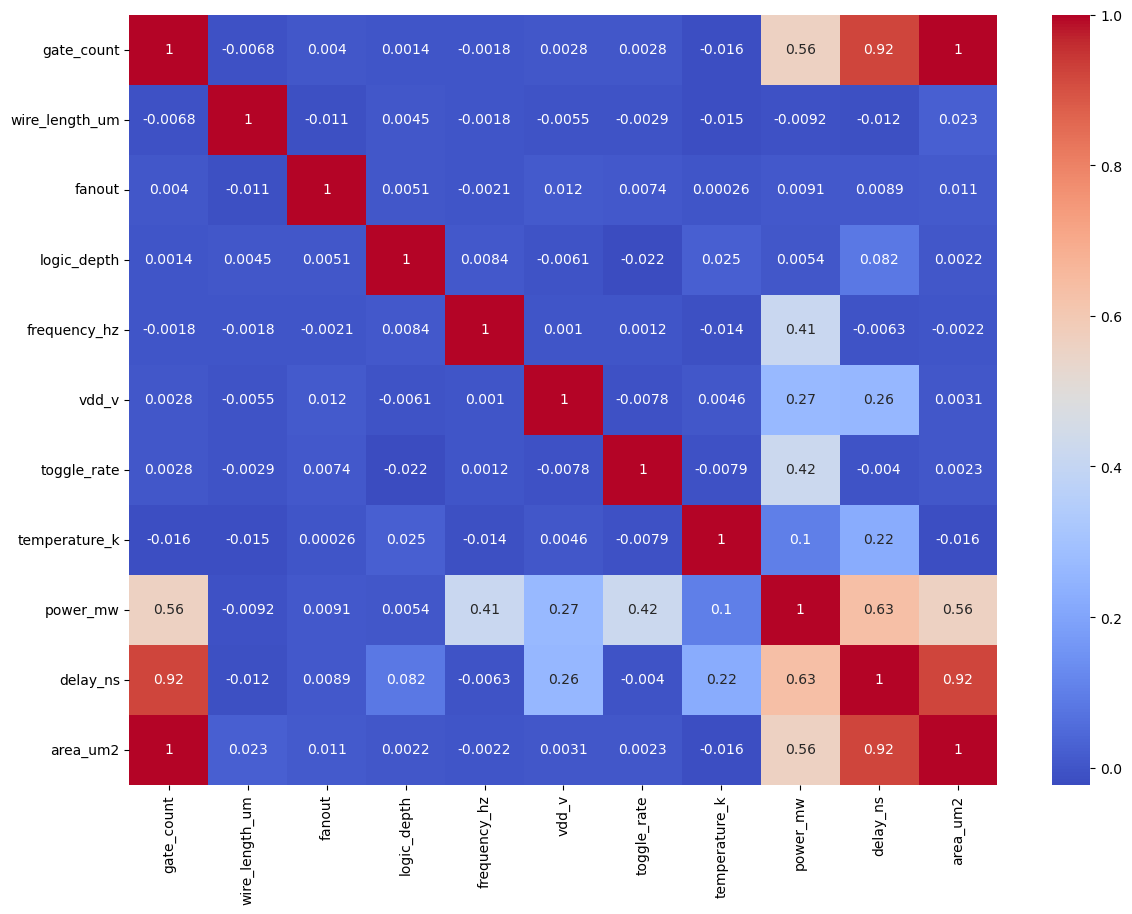

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
# 변수들 간의 상관관계(Correlation)를 Heatmap(열지도)으로 시각화
# 어떤 스펙이 Power나 Area와 강하게 연결(붉은색/푸른색)되어 있는지 멘티들과 확인하기 좋음
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [13]:
# x=설계조건, y=예측대상
#데이터 분할 및 Random Forest 베이스라인
# 1. 문제지(X)와 정답지(y) 분리
X = df[[
    'gate_count',
    'wire_length_um',
    'fanout',
    'logic_depth',
    'frequency_hz',
    'vdd_v',
    'toggle_rate',
    'temperature_k'
]]

y = df[[
    'power_mw',
    'delay_ns',
    'area_um2'
]]

In [82]:
from sklearn.model_selection import train_test_split
# 2. 전체 데이터 중 80%는 학습용, 20%는 평가(테스트)용으로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [83]:
from sklearn.ensemble import RandomForestRegressor
# 3. 딥러닝 전 비교 기준점(Baseline)이 될 Random Forest 모델 생성 및 학습
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
# 4. 평가용 문제(X_test)를 풀게 하고 점수 매기기
pred = model.predict(X_test)

In [85]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, pred))

120.39222330472934


In [86]:
from sklearn.metrics import mean_absolute_error
#delay 가 performance의 대리 proxy(대리지표)이기 때문에 예측한것이다.
targets = ['power_mw', 'delay_ns', 'area_um2']

for i, target in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], pred[:, i])
    print(f"{target}: {mae}")

power_mw: 3.2896755123167494
delay_ns: 3.1734632446102045
area_um2: 354.71353115726066


In [88]:
from sklearn.metrics import r2_score
print(r2_score(y_test, pred))

0.835428293394358


In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score # r2_score 추가

# 1. 모델 준비
model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
)

# 2. 모델 학습 (공부)
model.fit(X_train, y_train)

# 3. 모델 예측 (시험)
pred = model.predict(X_test)

# 4. 성능 평가 (채점)
print("R² (설명력):", r2_score(y_test, pred))
print("MAE (평균 오차):", mean_absolute_error(y_test, pred))

R² (설명력): 0.835428293394358
MAE (평균 오차): 120.39222330472934


In [93]:
pip install torch


   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
    --------------------------------------- 2.4/114.6 MB 11.8 MB/s eta 0:00:10
   - -------------------------------------- 4.7/114.6 MB 11.8 MB/s eta 0:00:10
   -- ------------------------------------- 6.8/114.6 MB 11.3 MB/s eta 0:00:10
   --- ------------------------------------ 8.9/114.6 MB 10.9 MB/s eta 0:00:10
   --- ------------------------------------ 11.3/114.6 MB 11.0 MB/s eta 0:00:10
   ---- ----------------------------------- 13.6/114.6 MB 11.0 MB/s eta 0:00:10
   ----- ---------------------------------- 16.0/114.6 MB 11.1 MB/s eta 0:00:09
   ------ --------------------------------- 18.4/114.6 MB 11.1 MB/s eta 0:00:09
   ------- -------------------------------- 20.4/114.6 MB 11.1 MB/s eta 0:00:09
   ------- -------------------------------- 22.8/114.6 MB 11.1 MB/s eta 0:00:09
   -------- ------------------------------- 25.4/114.6 MB 11.1 MB/s eta 0:00:09
   --------- ------------------------------ 27.8/114.

In [16]:
#딥러닝을 위한 필수 전처리 (스케일링 및 Tensor 변환)
#머신러닝(트리 기반)과 달리 딥러닝은 단위가 큰 변수(주파수: 10^9)가 
#단위가 작은 변수(전압: 1.2)를 압도해버릴 수 있어서 반드시 스케일링이 필요합니다.
import torch
import torch.nn as nn
import torch.optim as optim

In [17]:
#데이터 정규화 (매우 중요)
from sklearn.preprocessing import StandardScaler
# 1. 데이터 스케일링 (정규화) - 평균을 0, 분산을 1로 맞춰 단위 차이를 없앰
x_scaler = StandardScaler()
y_scaler = StandardScaler()
# fit_transform: 학습 데이터 기준으로 기준점을 잡고(fit) 변환(transform)
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
# transform: 학습 데이터 기준으로 잡아둔 기준점을 테스트 데이터에 동일하게 적용
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

NameError: name 'X_train' is not defined

In [ ]:
#Tensor 변환 
# 2. PyTorch용 Tensor 타입으로 데이터 형식 변환 
#(GPU 연산 및 딥러닝 모델 입력을 위해 필수)
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

y_train_tensor = torch.FloatTensor(y_train_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

In [18]:
#신경망 정의
# PyTorch의 nn.Module을 상속받아 나만의 신경망 클래스 생성
class PPANet(nn.Module):
    def __init__(self):
        super(PPANet, self).__init__()
        # 모델 구조 정의 (Sequential: 순차적으로 데이터가 통과함)
        self.model = nn.Sequential(
            nn.Linear(8, 64), # 입력층: 8개의 입력(설계 조건)을 받아 64개로 늘림
            nn.ReLU(), # 활성화 함수: 비선형 패턴을 학습하게 해줌 (음수는 0으로 처리)

            nn.Linear(64, 128), # 은닉층 1: 64개 -> 128개
            nn.ReLU(),

            nn.Linear(128, 64), # 은닉층 2: 128개 -> 64개
            nn.ReLU(),

            nn.Linear(64, 3) # 출력층: 최종적으로 3개의 예측값(Power, Delay, Area)을 내놓음
        )
# 순전파: 데이터가 들어와서 예측값을 내보내는 과정
    def forward(self, x):
        return self.model(x)

In [9]:
import torch

In [10]:
checkpoint = torch.load("ppa_model.pth", map_location="cpu")
print(checkpoint.keys())

odict_keys(['model.0.weight', 'model.0.bias', 'model.2.weight', 'model.2.bias', 'model.4.weight', 'model.4.bias', 'model.6.weight', 'model.6.bias'])


In [101]:
#모델 생성 # 모델 뼈대 생성
model = PPANet()
# 오차를 계산하는 함수 설정 (MSELoss: 실제 정답과 예측값의 차이를 제곱하여 평균 냄)
criterion = nn.MSELoss()
# 모델을 똑똑하게 만드는 최적화 알고리즘 (Adam 사용, 학습률 0.001)
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [102]:
#학습
epochs = 300 # 전체 데이터를 300번 반복해서 공부함

for epoch in range(epochs):
# 1. 순전파: 현재 모델 상태로 X 데이터를 넣어 예측값(outputs) 도출
    outputs = model(X_train_tensor)
# 2. 오차 계산: 예측값과 실제 정답(y_train) 사이의 차이 계산
    loss = criterion(outputs, y_train_tensor)
# 3. 기울기 초기화: PyTorch는 기울기를 누적하는 성질이 있어 매 루프마다 0으로 비워줘야 함
    optimizer.zero_grad()
# 4. 오차 역전파: 오차를 거꾸로 전파하여 각 가중치(신경망의 연결강도)가 오차에 미친 영향을 계산
    loss.backward()
# 5. 가중치 업데이트: 계산된 영향을 바탕으로 오차를 줄이는 방향으로 가중치를 수정
    optimizer.step()
# 50번 학습할 때마다 현재 진행 상황과 오차(Loss) 출력
    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/300], Loss: 0.0477
Epoch [100/300], Loss: 0.0110
Epoch [150/300], Loss: 0.0075
Epoch [200/300], Loss: 0.0059
Epoch [250/300], Loss: 0.0048
Epoch [300/300], Loss: 0.0041


In [103]:
#예측 # 평가 모드: 학습을 멈추고 예측만 수행 (가중치 업데이트를 막음)
with torch.no_grad():
    pred_scaled = model(X_test_tensor).numpy() # 테스트 데이터 예측 결과 도출
# 스케일링(압축)되어 있는 예측값을 원래의 물리적 수치(mW, ns, um²)로 복구
pred = y_scaler.inverse_transform(pred_scaled)

In [104]:
#평가 # 모델의 종합 성능 점수 출력
print("R²:", r2_score(y_test, pred))

targets = ['power_mw', 'delay_ns', 'area_um2']
# P, P, A 각각의 오차(MAE) 출력
for i, target in enumerate(targets):
    mae = mean_absolute_error(y_test.iloc[:, i], pred[:, i])
    print(f"{target}: {mae}")

R²: 0.9950003027915955
power_mw: 0.4881072816778404
delay_ns: 0.5955314235633072
area_um2: 546.6099975368253


In [105]:
#실제 vs 예측 그래프 3개

In [106]:
#POWER

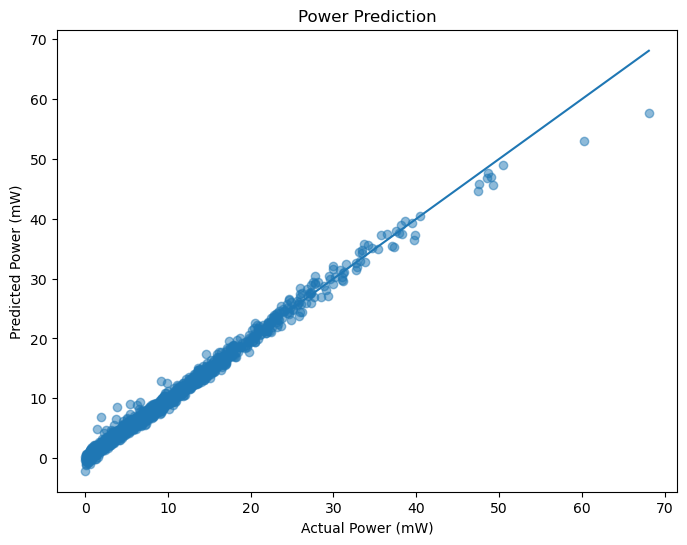

In [109]:
import matplotlib.pyplot as plt
# 실제값 vs 예측값 산점도(Scatter plot) 시각화 (Power 기준)
# 데이터가 대각선에 몰려 있을수록 예측이 정확하다는 의미
plt.figure(figsize=(8,6))
plt.scatter(y_test['power_mw'], pred[:,0], alpha=0.5)
plt.xlabel("Actual Power (mW)")
plt.ylabel("Predicted Power (mW)")
plt.title("Power Prediction")

plt.plot(
    [y_test['power_mw'].min(), y_test['power_mw'].max()],
    [y_test['power_mw'].min(), y_test['power_mw'].max()]
)

plt.show()

In [110]:
#과적합인지 아닌지 확인, 학습 데이터 점수와 테스트 데이터 점수를 비교
with torch.no_grad():
    train_pred_scaled = model(X_train_tensor).numpy()

train_pred = y_scaler.inverse_transform(train_pred_scaled)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, pred))
#과접합 아니라 low-noise physics-informed synthetic regression 이다. 
# = 규칙이 선명한 데이터를 잘 학습한 것.
# Train R²와 Test R²가 비슷하게 높다면 과적합 없이 학습이 매우 잘 된 것임.

Train R²: 0.9959571957588196
Test R² : 0.9950003027915955


In [107]:
#Delay

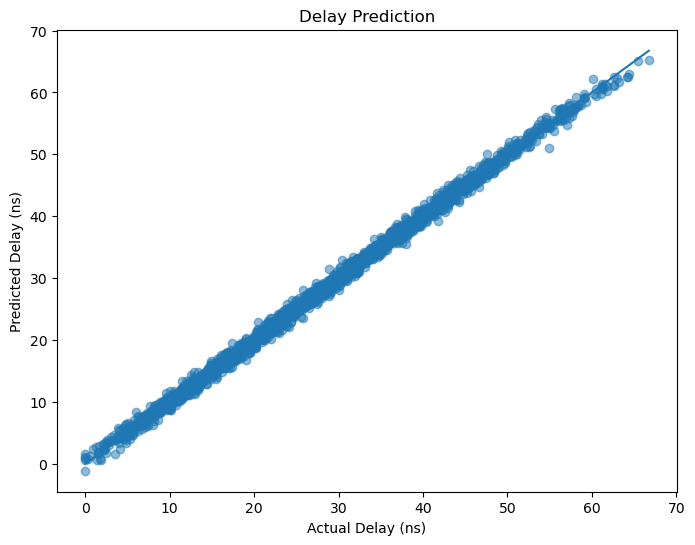

In [111]:
plt.figure(figsize=(8,6))
plt.scatter(y_test['delay_ns'], pred[:,1], alpha=0.5)

plt.xlabel("Actual Delay (ns)")
plt.ylabel("Predicted Delay (ns)")
plt.title("Delay Prediction")

plt.plot(
    [y_test['delay_ns'].min(), y_test['delay_ns'].max()],
    [y_test['delay_ns'].min(), y_test['delay_ns'].max()]
)

plt.show()

In [112]:
#Area

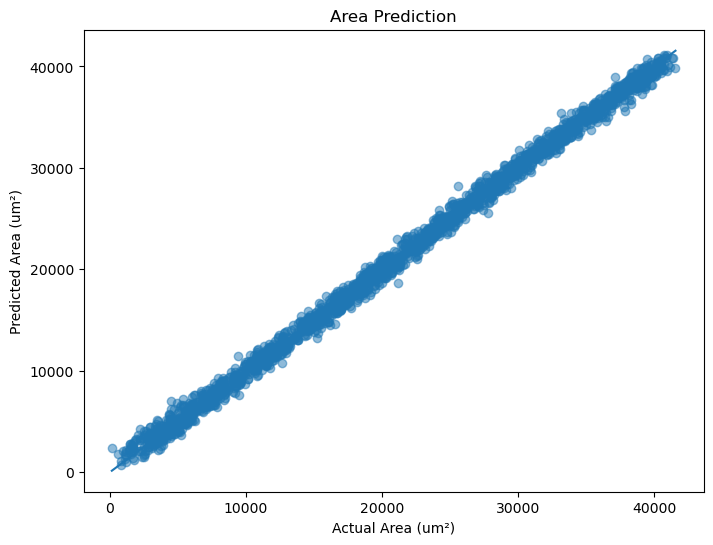

In [113]:
plt.figure(figsize=(8,6))
plt.scatter(y_test['area_um2'], pred[:,2], alpha=0.5)

plt.xlabel("Actual Area (um²)")
plt.ylabel("Predicted Area (um²)")
plt.title("Area Prediction")

plt.plot(
    [y_test['area_um2'].min(), y_test['area_um2'].max()],
    [y_test['area_um2'].min(), y_test['area_um2'].max()]
)

plt.show()

In [114]:
#모델 저장
# 1. 학습된 모델의 가중치(뇌 구조)를 .pth 파일로 영구 저장
torch.save(model.state_dict(), "ppa_model.pth")

In [115]:
# scaler도 저장 -> Jupyter에서 학습 끝난 모델을 웹에서 다시 불러와야 함.
import joblib
# 2. 웹에서 입력받은 새로운 데이터를 변환하기 위해, 학습에 사용했던 스케일러 객체도 저장
joblib.dump(x_scaler, "x_scaler.pkl")
joblib.dump(y_scaler, "y_scaler.pkl")

['y_scaler.pkl']

In [116]:
# 파일이 잘 생성되었는지 폴더 확인
import os
print(os.listdir())

['.ipynb_checkpoints', 'data_generation.ipynb', 'KUPY2.csv', 'ppa_model.pth', 'project_filebrowser.db', 'x_scaler.pkl', 'y_scaler.pkl']


In [119]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [5]:
!Streamlit --version

Streamlit, version 1.57.0
